<a href="https://www.kaggle.com/code/linaai/notebook9deae2ed42?scriptVersionId=159223347" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
#importing libararies.
import pandas as pd# store data into row &column/read data.
import numpy as np#to perform calculation.
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
#default theme
sns.set_theme()

In [2]:
#Loading datafile into panda dataframe.
data=pd.read_csv('/kaggle/input/body-signal-of-smoking/smoking.csv')
data
#data.tail()# display last 5 row

,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,81.3,1.2,1.0,1.0,1.0,...,12.9,1.0,0.7,18.0,19.0,27.0,Y,0,Y,0
1,1,F,40,160,60,81.0,0.8,0.6,1.0,1.0,...,12.7,1.0,0.6,22.0,19.0,18.0,Y,0,Y,0
2,2,M,55,170,60,80.0,0.8,0.8,1.0,1.0,...,15.8,1.0,1.0,21.0,16.0,22.0,Y,0,N,1
3,3,M,40,165,70,88.0,1.5,1.5,1.0,1.0,...,14.7,1.0,1.0,19.0,26.0,18.0,Y,0,Y,0
4,4,F,40,155,60,86.0,1.0,1.0,1.0,1.0,...,12.5,1.0,0.6,16.0,14.0,22.0,Y,0,N,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55687,55676,F,40,170,65,75.0,0.9,0.9,1.0,1.0,...,12.3,1.0,0.6,14.0,7.0,10.0,Y,1,Y,0
55688,55681,F,45,160,50,70.0,1.2,1.2,1.0,1.0,...,14.0,1.0,0.9,20.0,12.0,14.0,Y,0,Y,0
55689,55683,F,55,160,50,68.5,1.0,1.2,1.0,1.0,...,12.4,1.0,0.5,17.0,11.0,12.0,Y,0,N,0
55690,55684,M,60,165,60,78.0,0.8,1.0,1.0,1.0,...,14.4,1.0,0.7,20.0,19.0,18.0,Y,0,N,0


In [3]:
#display the dataframe (first 5 row).
data.head()

,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,81.3,1.2,1.0,1.0,1.0,...,12.9,1.0,0.7,18.0,19.0,27.0,Y,0,Y,0
1,1,F,40,160,60,81.0,0.8,0.6,1.0,1.0,...,12.7,1.0,0.6,22.0,19.0,18.0,Y,0,Y,0
2,2,M,55,170,60,80.0,0.8,0.8,1.0,1.0,...,15.8,1.0,1.0,21.0,16.0,22.0,Y,0,N,1
3,3,M,40,165,70,88.0,1.5,1.5,1.0,1.0,...,14.7,1.0,1.0,19.0,26.0,18.0,Y,0,Y,0
4,4,F,40,155,60,86.0,1.0,1.0,1.0,1.0,...,12.5,1.0,0.6,16.0,14.0,22.0,Y,0,N,0


In [4]:
#information about dataframe.
#data.dtypes to show only data type feature.
data.info()

data = data.drop("ID",axis = 1) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55692 entries, 0 to 55691
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   55692 non-null  int64  
 1   gender               55692 non-null  object 
 2   age                  55692 non-null  int64  
 3   height(cm)           55692 non-null  int64  
 4   weight(kg)           55692 non-null  int64  
 5   waist(cm)            55692 non-null  float64
 6   eyesight(left)       55692 non-null  float64
 7   eyesight(right)      55692 non-null  float64
 8   hearing(left)        55692 non-null  float64
 9   hearing(right)       55692 non-null  float64
 10  systolic             55692 non-null  float64
 11  relaxation           55692 non-null  float64
 12  fasting blood sugar  55692 non-null  float64
 13  Cholesterol          55692 non-null  float64
 14  triglyceride         55692 non-null  float64
 15  HDL                  55692 non-null 

In [5]:
#number of recored in dataset.
len(data)

55692

In [6]:
#Calculating related summary statistics (numaric feature).
data.describe()
#count=no. of record
#mean=sum of example/ total no. of example.
#std=square root of var(how sample deviate from mean).
#box plot(min-Q1-middel-Q3-max)

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
count,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,...,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000
mean,44.182917,164.649321,65.864936,82.046418,1.012623,1.007443,1.025587,1.026144,121.494218,76.004830,...,57.290347,114.964501,14.622592,1.087212,0.885738,26.182935,27.036037,39.952201,0.213334,0.367288
std,12.071418,9.194597,12.820306,9.274223,0.486873,0.485964,0.157902,0.159564,13.675989,9.679278,...,14.738963,40.926476,1.564498,0.404882,0.221524,19.355460,30.947853,50.290539,0.409665,0.482070
min,20.000000,130.000000,30.000000,51.000000,0.100000,0.100000,1.000000,1.000000,71.000000,40.000000,...,4.000000,1.000000,4.900000,1.000000,0.100000,6.000000,1.000000,1.000000,0.000000,0.000000
25%,40.000000,160.000000,55.000000,76.000000,0.800000,0.800000,1.000000,1.000000,112.000000,70.000000,...,47.000000,92.000000,13.600000,1.000000,0.800000,19.000000,15.000000,17.000000,0.000000,0.000000
50%,40.000000,165.000000,65.000000,82.000000,1.000000,1.000000,1.000000,1.000000,120.000000,76.000000,...,55.000000,113.000000,14.800000,1.000000,0.900000,23.000000,21.000000,25.000000,0.000000,0.000000
75%,55.000000,170.000000,75.000000,88.000000,1.200000,1.200000,1.000000,1.000000,130.000000,82.000000,...,66.000000,136.000000,15.800000,1.000000,1.000000,28.000000,31.000000,43.000000,0.000000,1.000000
max,85.000000,190.000000,135.000000,129.000000,9.900000,9.900000,2.000000,2.000000,240.000000,146.000000,...,618.000000,1860.000000,21.100000,6.000000,11.600000,1311.000000,2914.000000,999.000000,1.000000,1.000000


In [7]:
#show correlation matrix for all variable.
data.corr(numeric_only =True)
#data.corr().round(1)
#value in range[1,-1]
#value->1:positive realation
#value->-1:neqative realation
#value->0 from both side: no realation

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
age,1.000000,-0.479528,-0.324706,-0.026297,-0.195472,-0.192723,0.203993,0.208722,0.134023,0.050745,...,0.007047,0.043007,-0.263078,0.029625,-0.106118,0.032576,-0.063937,0.013031,-0.114984,-0.162557
height(cm),-0.479528,1.000000,0.675656,0.378902,0.151133,0.155665,-0.078663,-0.078323,0.080585,0.113193,...,-0.213284,-0.048419,0.539367,0.005128,0.383883,0.041737,0.126511,0.139720,0.079331,0.396675
weight(kg),-0.324706,0.675656,1.000000,0.822842,0.108433,0.113155,-0.050094,-0.052836,0.266131,0.271634,...,-0.358868,0.040560,0.492970,0.032566,0.324808,0.120130,0.250634,0.209625,0.073536,0.302780
waist(cm),-0.026297,0.378902,0.822842,1.000000,0.027458,0.037996,0.023790,0.019286,0.316922,0.292627,...,-0.376203,0.072817,0.387066,0.045492,0.235024,0.142690,0.252478,0.243141,0.044203,0.226259
eyesight(left),-0.195472,0.151133,0.108433,0.027458,1.000000,0.354574,-0.046571,-0.048788,-0.019330,0.005199,...,-0.015296,-0.007257,0.095234,-0.002752,0.071410,-0.007966,0.019326,0.003850,0.003684,0.061204
eyesight(right),-0.192723,0.155665,0.113155,0.037996,0.354574,1.000000,-0.043877,-0.046623,-0.013720,0.011357,...,-0.022220,-0.006172,0.096119,-0.013511,0.047608,-0.006921,0.024182,0.012195,0.016359,0.063017
hearing(left),0.203993,-0.078663,-0.050094,0.023790,-0.046571,-0.043877,1.000000,0.510095,0.055219,0.008754,...,-0.020159,-0.016706,-0.026116,0.014527,0.003349,0.018074,0.004820,0.012864,-0.016100,-0.023209
hearing(right),0.208722,-0.078323,-0.052836,0.019286,-0.048788,-0.046623,0.510095,1.000000,0.049095,0.001651,...,-0.017986,-0.015426,-0.030943,0.019461,0.008060,0.009393,-0.005081,0.009245,-0.016376,-0.018855
systolic,0.134023,0.080585,0.266131,0.316922,-0.019330,-0.013720,0.055219,0.049095,1.000000,0.761051,...,-0.088487,0.016569,0.186514,0.046170,0.072288,0.083204,0.094893,0.165724,0.029894,0.073109
relaxation,0.050745,0.113193,0.271634,0.292627,0.005199,0.011357,0.008754,0.001651,0.761051,1.000000,...,-0.089410,0.041017,0.232899,0.045665,0.085033,0.085151,0.106648,0.177648,0.031634,0.108309


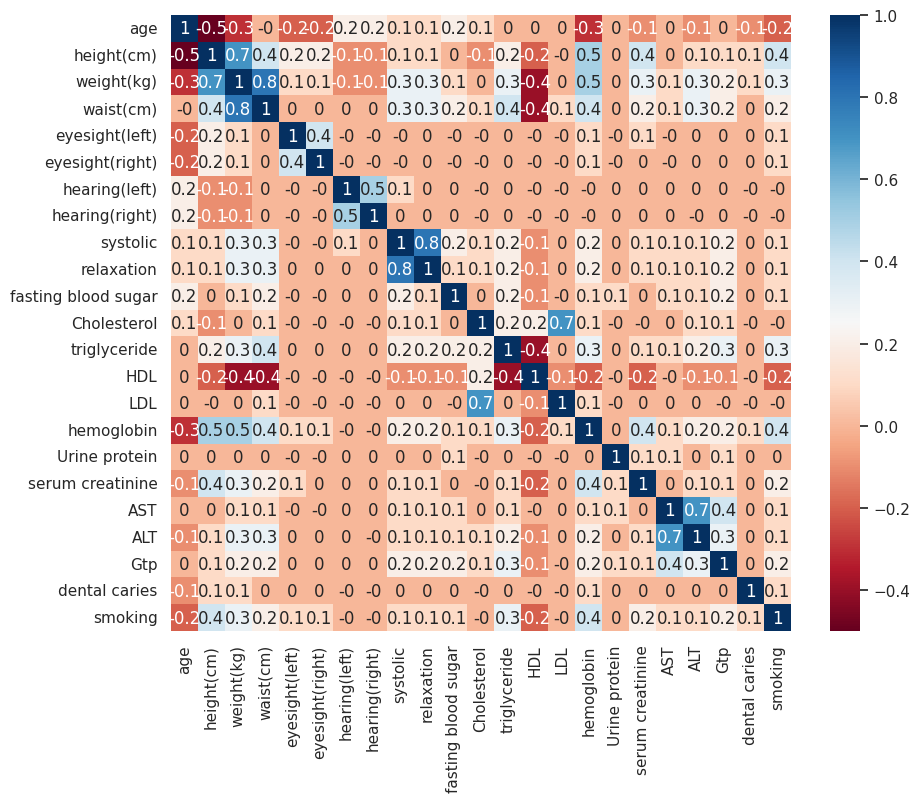

In [8]:
#Correlations Heatmap=value of corealtion in form of color(cmap ( is parameter))(Rd=red,Bu=Blue).
#annot=a notation(values)
corrHeatMap=data.corr(numeric_only =True).round(1)
plt.figure(figsize=(10, 8))
sns.heatmap(corrHeatMap,cmap='RdBu',annot=True)
plt.show()

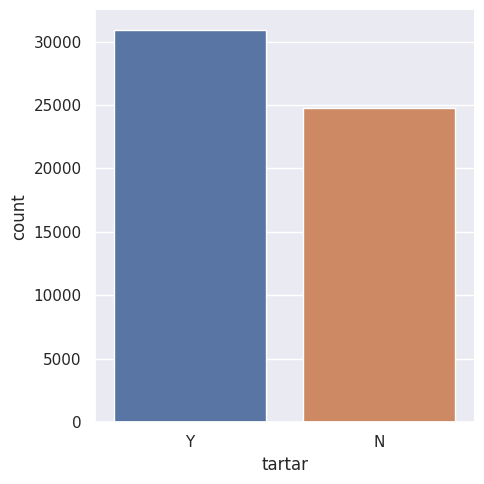

In [9]:
#plotting the bar chart for categorical column-count of this categorical
sns.catplot(x='tartar',kind='count',data=data)

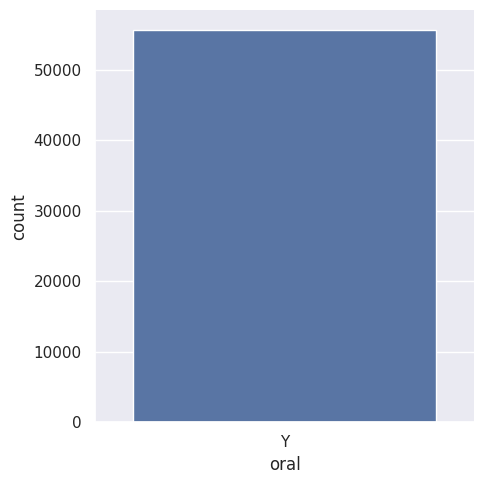

In [10]:
#plotting the bar chart for categorical column-count of this categorical
sns.catplot(x='oral',kind='count',data=data)

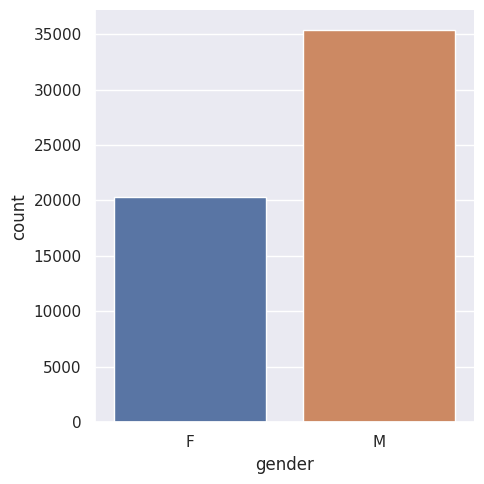

In [11]:
#plotting the bar chart for categorical column-count of this categorical
sns.catplot(x='gender',kind='count',data=data)

In [12]:
#show columns
data.columns

Index(['gender', 'age', 'height(cm)', 'weight(kg)', 'waist(cm)',
       'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)',
       'systolic', 'relaxation', 'fasting blood sugar', 'Cholesterol',
       'triglyceride', 'HDL', 'LDL', 'hemoglobin', 'Urine protein',
       'serum creatinine', 'AST', 'ALT', 'Gtp', 'oral', 'dental caries',
       'tartar', 'smoking'],
      dtype='object')

In [13]:
#list of dataframe
columns=list(data)
columns

['gender',
 'age',
 'height(cm)',
 'weight(kg)',
 'waist(cm)',
 'eyesight(left)',
 'eyesight(right)',
 'hearing(left)',
 'hearing(right)',
 'systolic',
 'relaxation',
 'fasting blood sugar',
 'Cholesterol',
 'triglyceride',
 'HDL',
 'LDL',
 'hemoglobin',
 'Urine protein',
 'serum creatinine',
 'AST',
 'ALT',
 'Gtp',
 'oral',
 'dental caries',
 'tartar',
 'smoking']

In [14]:
x=pd.get_dummies(data)
x.head()

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,AST,ALT,Gtp,dental caries,smoking,gender_F,gender_M,oral_Y,tartar_N,tartar_Y
0,40,155,60,81.3,1.2,1.0,1.0,1.0,114.0,73.0,...,18.0,19.0,27.0,0,0,True,False,True,False,True
1,40,160,60,81.0,0.8,0.6,1.0,1.0,119.0,70.0,...,22.0,19.0,18.0,0,0,True,False,True,False,True
2,55,170,60,80.0,0.8,0.8,1.0,1.0,138.0,86.0,...,21.0,16.0,22.0,0,1,False,True,True,True,False
3,40,165,70,88.0,1.5,1.5,1.0,1.0,100.0,60.0,...,19.0,26.0,18.0,0,0,False,True,True,False,True
4,40,155,60,86.0,1.0,1.0,1.0,1.0,120.0,74.0,...,16.0,14.0,22.0,0,0,True,False,True,True,False


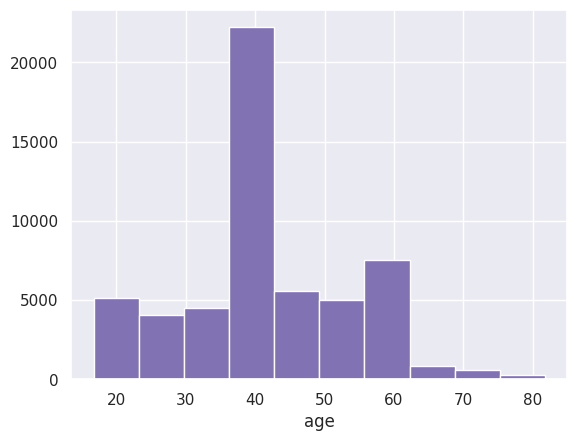

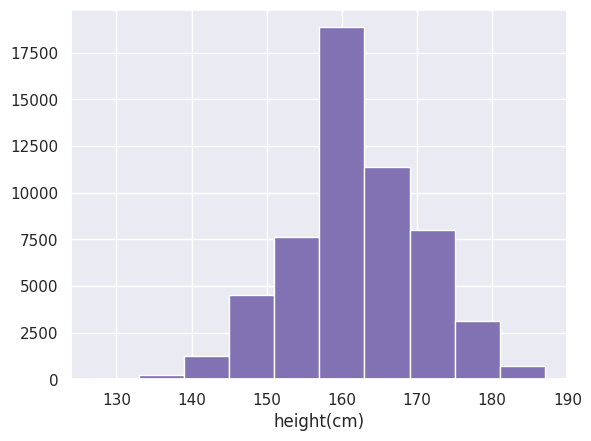

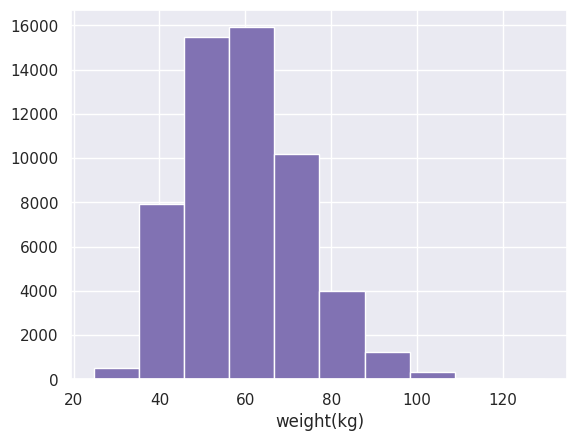

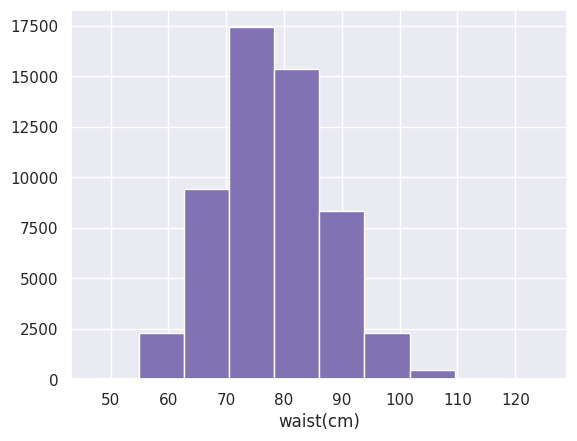

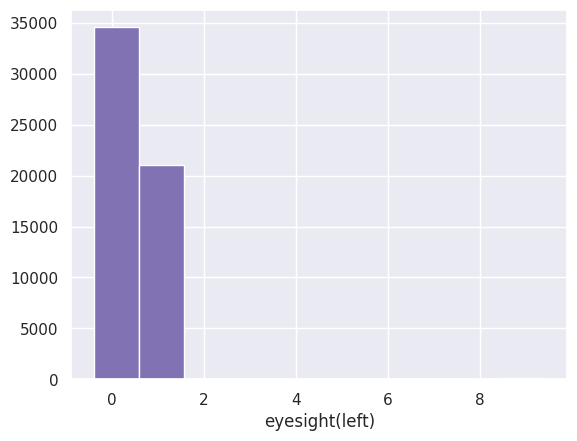

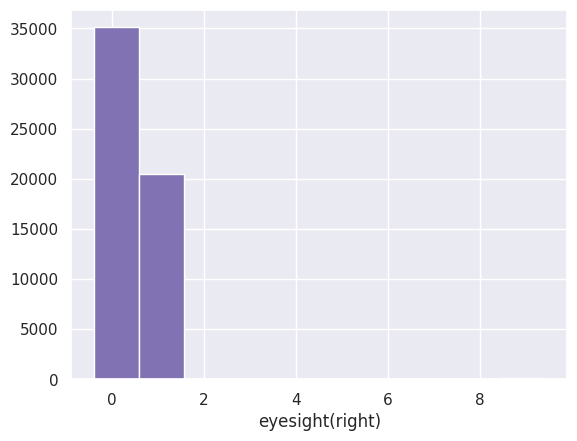

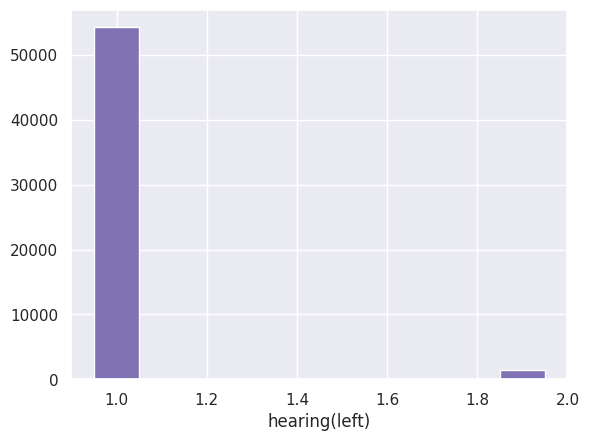

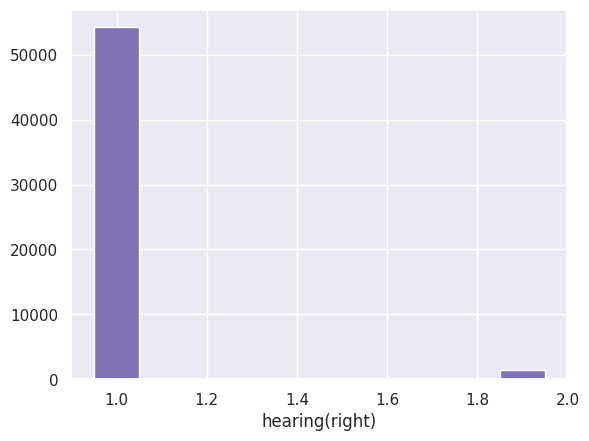

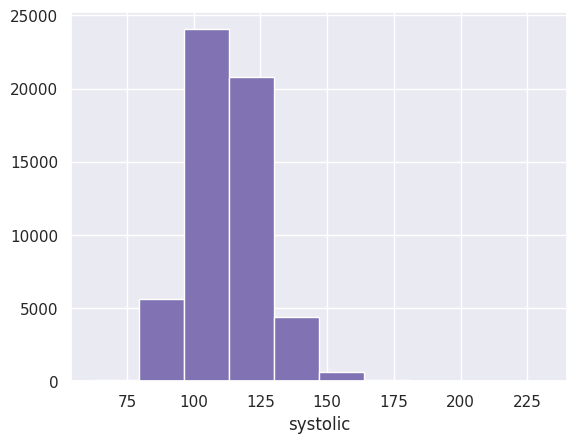

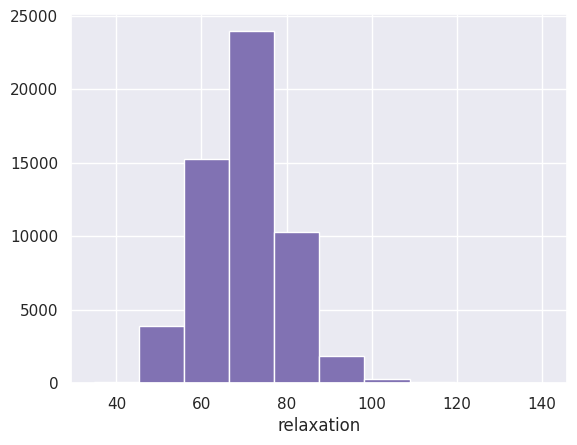

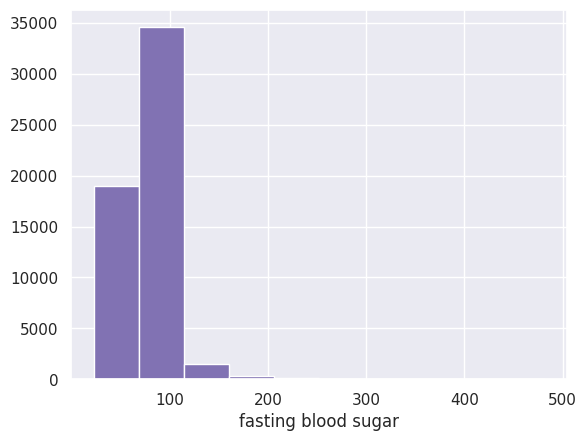

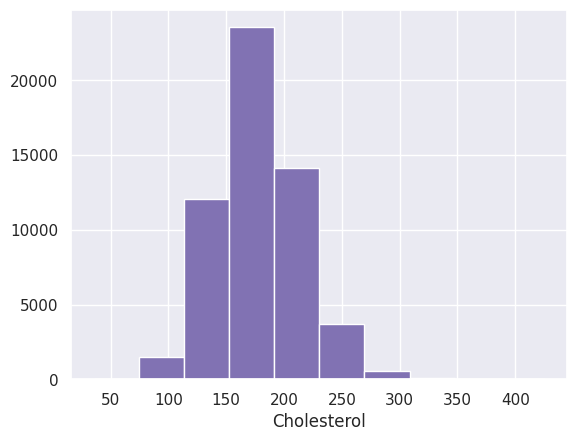

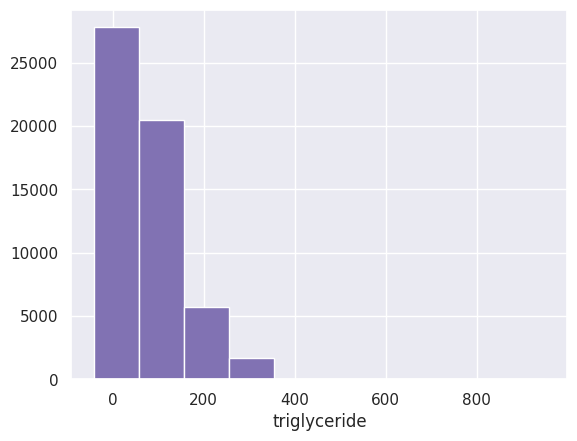

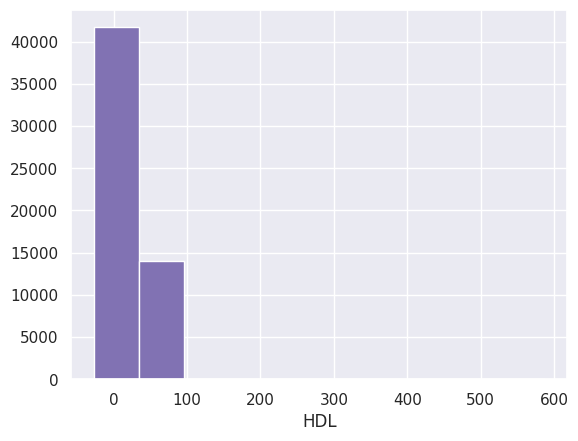

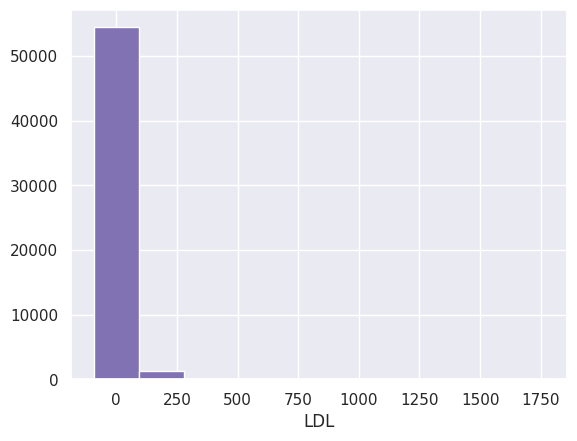

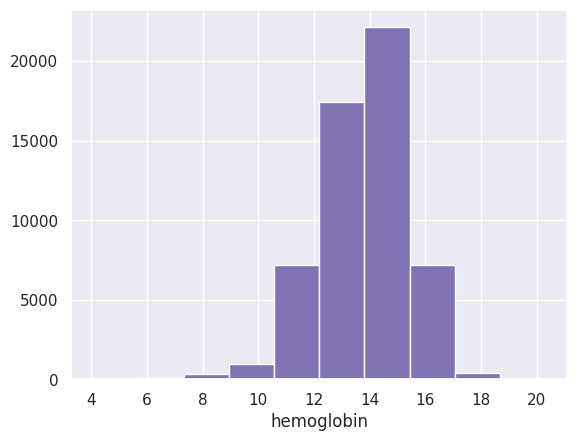

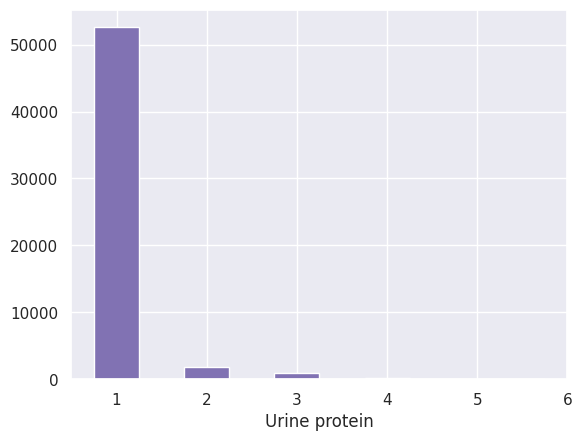

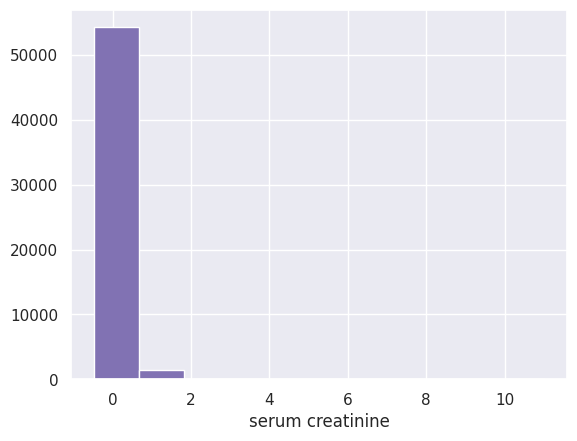

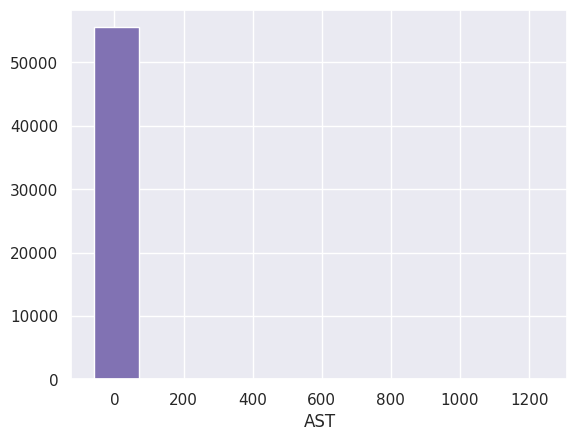

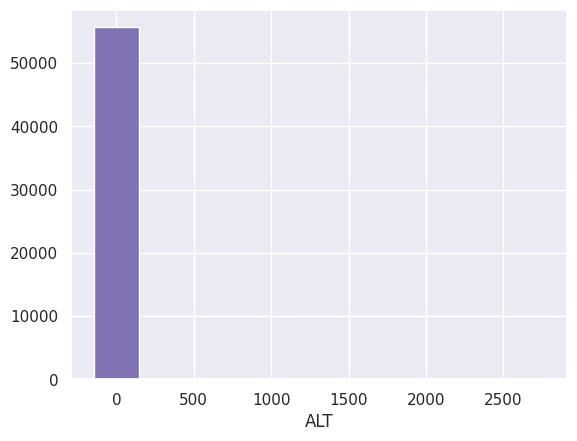

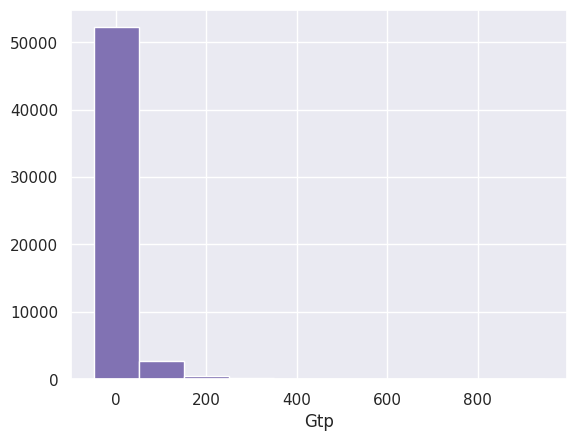

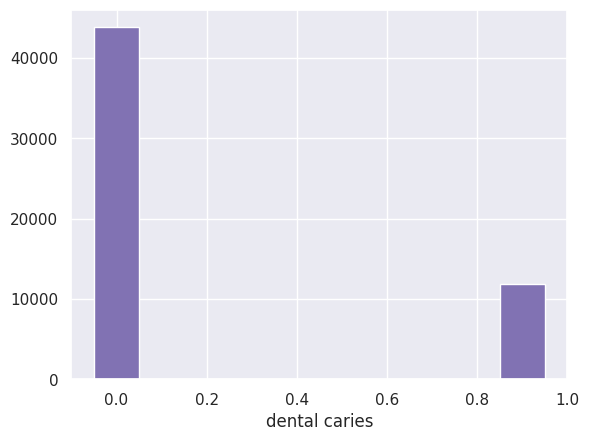

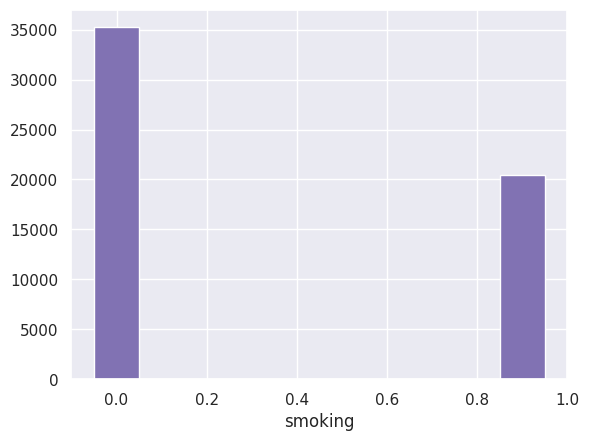

<__array_function__ internals>:200: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.


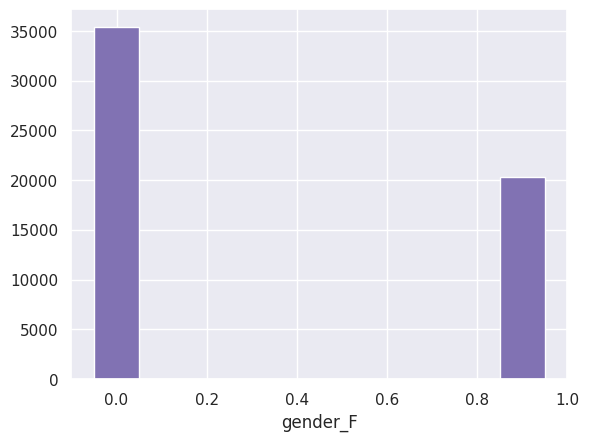

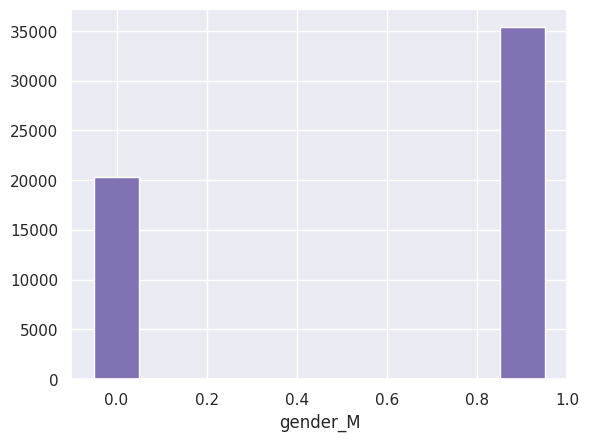

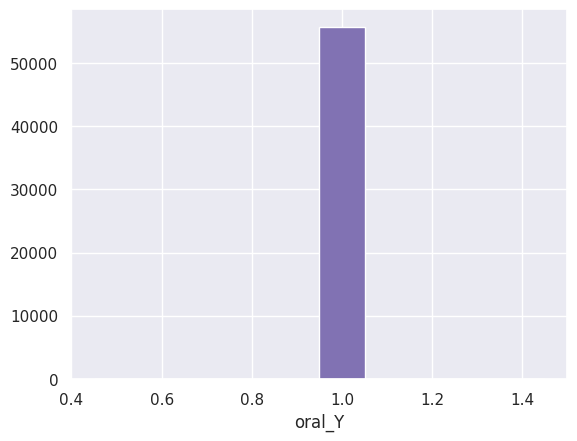

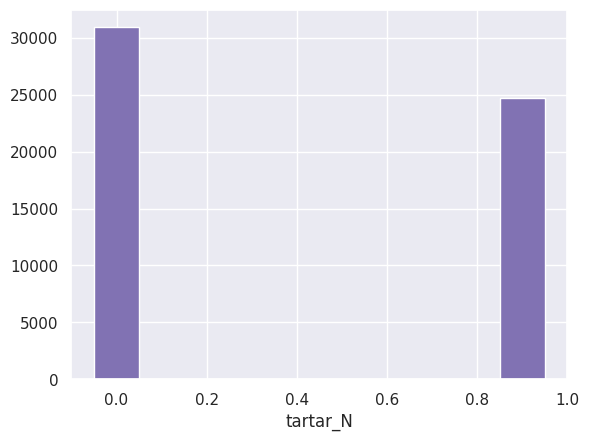

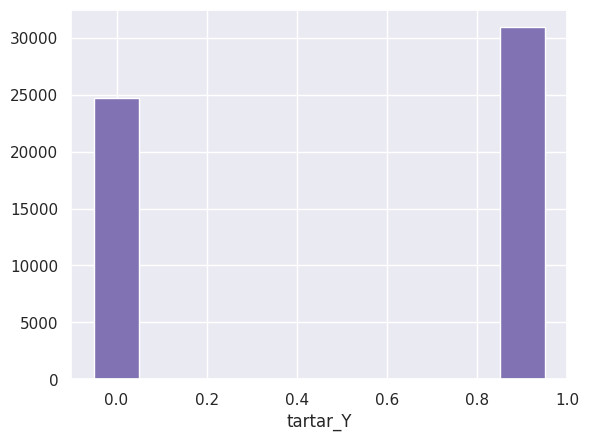

In [15]:
for i in x.columns:
    plt.figure()
    hist1,edges1=np.histogram(x[i])
    plt.bar(edges1[:-1],hist1,width=edges1[1:]-edges1[:-1],color='m')
    plt.xlabel(i)
    plt.show()

In [16]:
#pre_processing
data_pre=data.copy()
data_pre.head()

,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,F,40,155,60,81.3,1.2,1.0,1.0,1.0,114.0,...,12.9,1.0,0.7,18.0,19.0,27.0,Y,0,Y,0
1,F,40,160,60,81.0,0.8,0.6,1.0,1.0,119.0,...,12.7,1.0,0.6,22.0,19.0,18.0,Y,0,Y,0
2,M,55,170,60,80.0,0.8,0.8,1.0,1.0,138.0,...,15.8,1.0,1.0,21.0,16.0,22.0,Y,0,N,1
3,M,40,165,70,88.0,1.5,1.5,1.0,1.0,100.0,...,14.7,1.0,1.0,19.0,26.0,18.0,Y,0,Y,0
4,F,40,155,60,86.0,1.0,1.0,1.0,1.0,120.0,...,12.5,1.0,0.6,16.0,14.0,22.0,Y,0,N,0


In [17]:
#check1-presence of null values 
data_pre.isnull().sum()

gender                 0
age                    0
height(cm)             0
weight(kg)             0
waist(cm)              0
eyesight(left)         0
eyesight(right)        0
hearing(left)          0
hearing(right)         0
systolic               0
relaxation             0
fasting blood sugar    0
Cholesterol            0
triglyceride           0
HDL                    0
LDL                    0
hemoglobin             0
Urine protein          0
serum creatinine       0
AST                    0
ALT                    0
Gtp                    0
oral                   0
dental caries          0
tartar                 0
smoking                0
dtype: int64

no null value.

In [18]:
#check2-missing values
for value in data_pre.columns:
    print(value,":", sum(data_pre[value] == '?'))

gender : 0
age : 0
height(cm) : 0
weight(kg) : 0
waist(cm) : 0
eyesight(left) : 0
eyesight(right) : 0
hearing(left) : 0
hearing(right) : 0
systolic : 0
relaxation : 0
fasting blood sugar : 0
Cholesterol : 0
triglyceride : 0
HDL : 0
LDL : 0
hemoglobin : 0
Urine protein : 0
serum creatinine : 0
AST : 0
ALT : 0
Gtp : 0
oral : 0
dental caries : 0
tartar : 0
smoking : 0


no missing value.

In [19]:
#normalize numeric features.
numeric=list(data.select_dtypes(exclude='object').columns)
numeric.pop()
numeric

['age',
 'height(cm)',
 'weight(kg)',
 'waist(cm)',
 'eyesight(left)',
 'eyesight(right)',
 'hearing(left)',
 'hearing(right)',
 'systolic',
 'relaxation',
 'fasting blood sugar',
 'Cholesterol',
 'triglyceride',
 'HDL',
 'LDL',
 'hemoglobin',
 'Urine protein',
 'serum creatinine',
 'AST',
 'ALT',
 'Gtp',
 'dental caries']

In [20]:
data.head()

,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,F,40,155,60,81.3,1.2,1.0,1.0,1.0,114.0,...,12.9,1.0,0.7,18.0,19.0,27.0,Y,0,Y,0
1,F,40,160,60,81.0,0.8,0.6,1.0,1.0,119.0,...,12.7,1.0,0.6,22.0,19.0,18.0,Y,0,Y,0
2,M,55,170,60,80.0,0.8,0.8,1.0,1.0,138.0,...,15.8,1.0,1.0,21.0,16.0,22.0,Y,0,N,1
3,M,40,165,70,88.0,1.5,1.5,1.0,1.0,100.0,...,14.7,1.0,1.0,19.0,26.0,18.0,Y,0,Y,0
4,F,40,155,60,86.0,1.0,1.0,1.0,1.0,120.0,...,12.5,1.0,0.6,16.0,14.0,22.0,Y,0,N,0


In [21]:
x=data.drop(['smoking'],axis=1)
y=data.smoking
y.head()

0    0
1    0
2    1
3    0
4    0
Name: smoking, dtype: int64

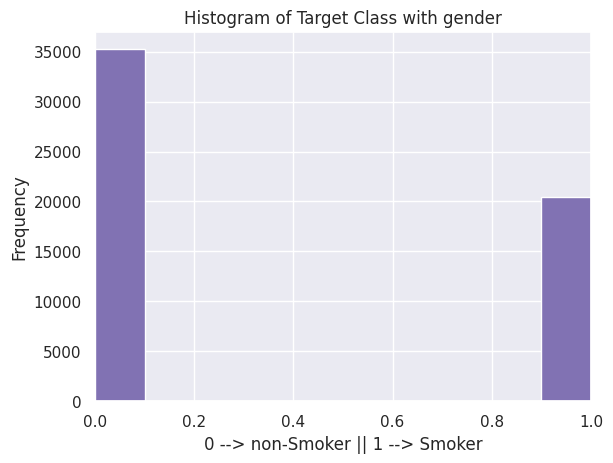

In [22]:
# adjust the font size 
plt.rcParams['font.size'] = 12

# plot histogram with 10 bins
plt.hist(y, bins = 10,color='m')
plt.hist(data["age"], bins = 10,color='blue')
plt.title('Histogram of Target Class with gender')
# set the x-axis limit
plt.xlim(0,1)
# set the title
plt.xlabel('0 --> non-Smoker || 1 --> Smoker')
plt.ylabel('Frequency')
plt.show()

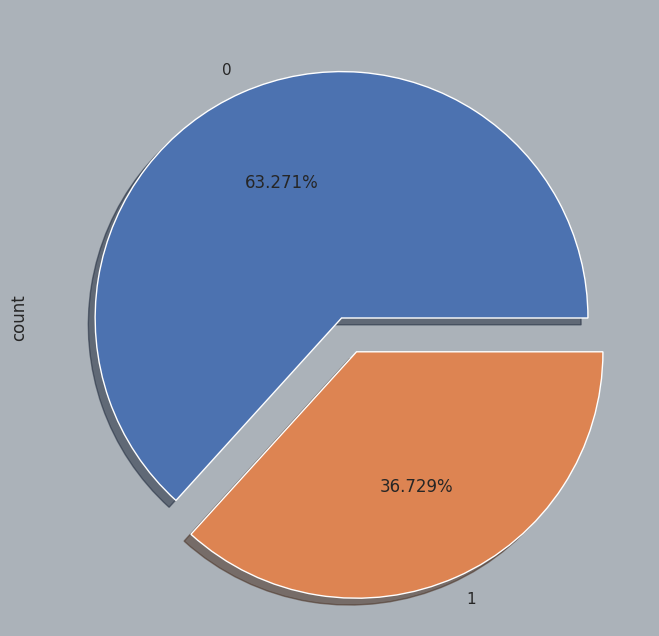

In [23]:
plt.figure(figsize = [8, 8], clear = True, facecolor = "#ABB2B9")
data["smoking"].value_counts().plot.pie(explode = [0, 0.15], autopct='%1.3f%%', shadow = True);


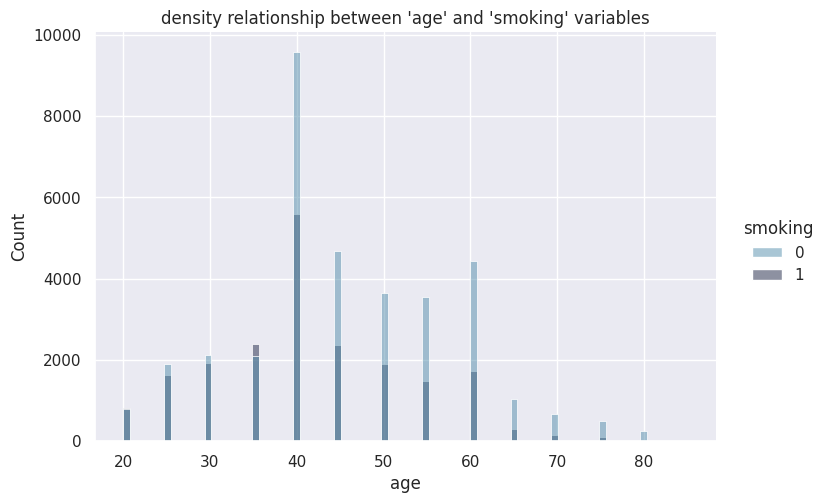

In [24]:
sns.displot(
    data = data, x = "age", hue = "smoking",
    kind = "hist", height = 5, aspect = 1.5,
    palette="ch:rot=-.25,hue=1,light=.50").set(title ="density relationship between 'age' and 'smoking' variables");

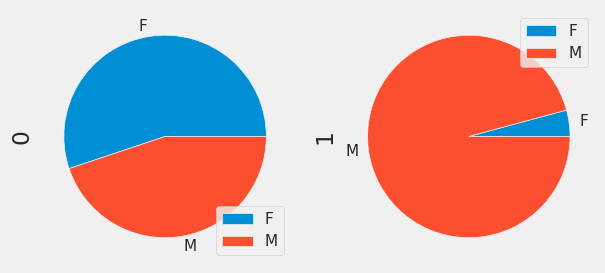

In [25]:
plt.style.use('fivethirtyeight')
pd.crosstab(data['gender'], data['smoking'],
            normalize = True).plot(kind = "pie", subplots = True, stacked=True);

In [26]:
x.head()

,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar
0,F,40,155,60,81.3,1.2,1.0,1.0,1.0,114.0,...,126.0,12.9,1.0,0.7,18.0,19.0,27.0,Y,0,Y
1,F,40,160,60,81.0,0.8,0.6,1.0,1.0,119.0,...,127.0,12.7,1.0,0.6,22.0,19.0,18.0,Y,0,Y
2,M,55,170,60,80.0,0.8,0.8,1.0,1.0,138.0,...,151.0,15.8,1.0,1.0,21.0,16.0,22.0,Y,0,N
3,M,40,165,70,88.0,1.5,1.5,1.0,1.0,100.0,...,226.0,14.7,1.0,1.0,19.0,26.0,18.0,Y,0,Y
4,F,40,155,60,86.0,1.0,1.0,1.0,1.0,120.0,...,107.0,12.5,1.0,0.6,16.0,14.0,22.0,Y,0,N


In [27]:
x=pd.get_dummies(x)
x.head()

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,serum creatinine,AST,ALT,Gtp,dental caries,gender_F,gender_M,oral_Y,tartar_N,tartar_Y
0,40,155,60,81.3,1.2,1.0,1.0,1.0,114.0,73.0,...,0.7,18.0,19.0,27.0,0,True,False,True,False,True
1,40,160,60,81.0,0.8,0.6,1.0,1.0,119.0,70.0,...,0.6,22.0,19.0,18.0,0,True,False,True,False,True
2,55,170,60,80.0,0.8,0.8,1.0,1.0,138.0,86.0,...,1.0,21.0,16.0,22.0,0,False,True,True,True,False
3,40,165,70,88.0,1.5,1.5,1.0,1.0,100.0,60.0,...,1.0,19.0,26.0,18.0,0,False,True,True,False,True
4,40,155,60,86.0,1.0,1.0,1.0,1.0,120.0,74.0,...,0.6,16.0,14.0,22.0,0,True,False,True,True,False


In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.25,random_state=5,stratify = y)# stratify =unblanced data

In [30]:
from sklearn.naive_bayes import GaussianNB
GNB=GaussianNB()
GNB.fit(X_train,Y_train)

GaussianNB()

In [31]:
Y_pred_train=GNB.predict(X_train)

In [32]:
from sklearn.metrics import f1_score
train_Accuracy=f1_score(Y_train, Y_pred_train)
print("Train Accuracy:",train_Accuracy)

Train Accuracy: 0.6861391666243719


In [33]:
Y_pred_test = GNB.predict(X_test)

In [34]:
test_Accuracy=f1_score(Y_test, Y_pred_test)
print("Test Accuracy:",test_Accuracy)

Test Accuracy: 0.6893226176808267


In [35]:
from sklearn.metrics import confusion_matrix
print('Train confusion_matrix')
confusion_matrix(Y_train,Y_pred_train)

Train confusion_matrix


array([[15882, 10546],
       [ 1822, 13519]])

confusion matrix


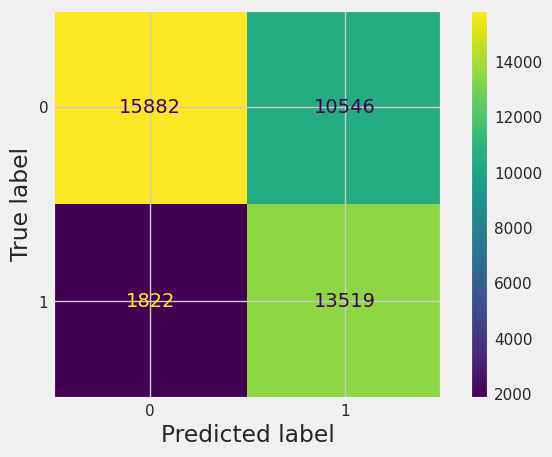

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay
print("confusion matrix")
confusion_matrix1 = confusion_matrix(Y_train,Y_pred_train)
display = ConfusionMatrixDisplay(confusion_matrix1).plot()

In [37]:
print("Test confusion_matrix")
confusion_matrix(Y_test, Y_pred_test)

Test confusion_matrix


array([[5361, 3448],
       [ 611, 4503]])

confusion matrix


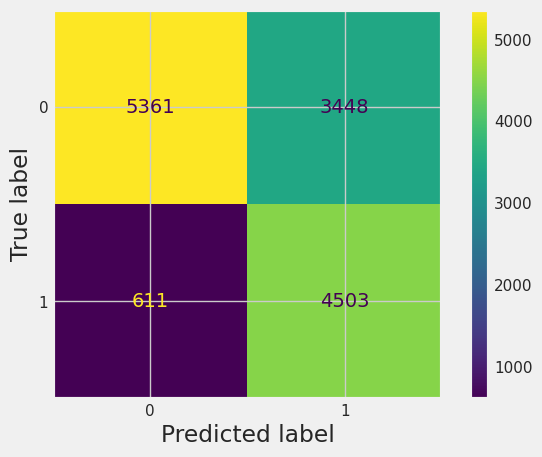

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay
print("confusion matrix")
confusion_matrix1=confusion_matrix(Y_test, Y_pred_test)
display=ConfusionMatrixDisplay(confusion_matrix1).plot()

In [39]:
from sklearn.metrics import classification_report
print('Train classification report')
print(classification_report(Y_train,Y_pred_train))

Train classification report
              precision    recall  f1-score   support

           0       0.90      0.60      0.72     26428
           1       0.56      0.88      0.69     15341

    accuracy                           0.70     41769
   macro avg       0.73      0.74      0.70     41769
weighted avg       0.77      0.70      0.71     41769



In [40]:
from sklearn.metrics import classification_report
print('Test classification report')
print(classification_report(Y_test, Y_pred_test))

Test classification report
              precision    recall  f1-score   support

           0       0.90      0.61      0.73      8809
           1       0.57      0.88      0.69      5114

    accuracy                           0.71     13923
   macro avg       0.73      0.74      0.71     13923
weighted avg       0.78      0.71      0.71     13923



In [41]:
#experiment
#feature selection.
indexes_to_drop = [9,13,14,15,16,19,20,21,22,23,24]
data1=data.drop(data.columns[indexes_to_drop], axis=1)
data1.head()

,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),relaxation,fasting blood sugar,Cholesterol,Urine protein,serum creatinine,smoking
0,F,40,155,60,81.3,1.2,1.0,1.0,1.0,73.0,94.0,215.0,1.0,0.7,0
1,F,40,160,60,81.0,0.8,0.6,1.0,1.0,70.0,130.0,192.0,1.0,0.6,0
2,M,55,170,60,80.0,0.8,0.8,1.0,1.0,86.0,89.0,242.0,1.0,1.0,1
3,M,40,165,70,88.0,1.5,1.5,1.0,1.0,60.0,96.0,322.0,1.0,1.0,0
4,F,40,155,60,86.0,1.0,1.0,1.0,1.0,74.0,80.0,184.0,1.0,0.6,0


In [42]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=5,stratify = y)

In [43]:
GNB1=GaussianNB()
GNB1.fit(x_train,y_train)

GaussianNB()

In [44]:
y_pred_train=GNB1.predict(x_train)

In [45]:
train_Accuracy1 = f1_score(y_train, Y_pred_train)
print("Train Accuracy:",train_Accuracy1)

Train Accuracy: 0.6861391666243719


In [46]:
y_pred_test = GNB1.predict(x_test)

In [47]:
test_Accuracy1 = f1_score(y_test, y_pred_test)
print("Test Accuracy:",test_Accuracy1)

Test Accuracy: 0.6893226176808267


In [48]:
from sklearn.metrics import confusion_matrix
print('Train confusion_matrix')
confusion_matrix(y_train,y_pred_train)

Train confusion_matrix


array([[15882, 10546],
       [ 1822, 13519]])

In [49]:
print("Test confusion_matrix")
confusion_matrix(y_test, y_pred_test)

Test confusion_matrix


array([[5361, 3448],
       [ 611, 4503]])

In [50]:
print('Train classification report')
print(classification_report(y_train,y_pred_train))

Train classification report
              precision    recall  f1-score   support

           0       0.90      0.60      0.72     26428
           1       0.56      0.88      0.69     15341

    accuracy                           0.70     41769
   macro avg       0.73      0.74      0.70     41769
weighted avg       0.77      0.70      0.71     41769



In [51]:
print('Test classification report')
print(classification_report(y_test, y_pred_test))

Test classification report
              precision    recall  f1-score   support

           0       0.90      0.61      0.73      8809
           1       0.57      0.88      0.69      5114

    accuracy                           0.71     13923
   macro avg       0.73      0.74      0.71     13923
weighted avg       0.78      0.71      0.71     13923



In [52]:
from sklearn.model_selection import GridSearchCV
# Hyperparameter tuning using GridSearchCV
params_NB = {'var_smoothing': np.logspace(0,-9, num=100)}
grid_search = GridSearchCV(estimator = GNB, param_grid=params_NB, cv=5,scoring='f1')
grid_search.fit(X_train, Y_train)
print("Best hyperparameters:", grid_search.best_params_)
print("Best cross-validation score: {:.2f}%".format(grid_search.best_score_ * 100))

# Evaluate the model with the best hyperparameters on the testing set.
best_clf = grid_search.best_estimator_
Y_pred_test = best_clf.predict(X_test)
test_acc1 = f1_score(Y_test, Y_pred_test)
print("Testing accuracy with best hyperparameters: {:.2f}%".format(test_acc1 * 100))

Best hyperparameters: {'var_smoothing': 6.579332246575682e-07}
Best cross-validation score: 68.57%
Testing accuracy with best hyperparameters: 68.97%


In [53]:
from sklearn.model_selection import RandomizedSearchCV

# Define the hyperparameter grid
param_dist = {'var_smoothing': np.logspace(0,-9, num=100)}

# Perform randomized search on the pipeline
random_search = RandomizedSearchCV(estimator = GNB,param_distributions = param_dist,n_iter=10,cv=5,scoring='f1',random_state=42)
random_search.fit(X_train, Y_train)

# Evaluate the performance of the best model on the test data
Y_pred_test = random_search.best_estimator_.predict(X_test)
test_acc = f1_score(Y_test, Y_pred_test)
# Print the best hyperparameters and number of selected features
print('Best hyperparameters:', random_search.best_params_)
print("Best cross-validation score: {:.2f}%".format(random_search.best_score_ * 100))

best_clf = random_search.best_estimator_
Y_pred_test = best_clf.predict(X_test)
test_acc2 = f1_score(Y_test, Y_pred_test)
print("Testing accuracy with best hyperparameters: {:.2f}%".format(test_acc2 * 100))

Best hyperparameters: {'var_smoothing': 2.848035868435799e-08}
Best cross-validation score: 68.56%
Testing accuracy with best hyperparameters: 68.93%


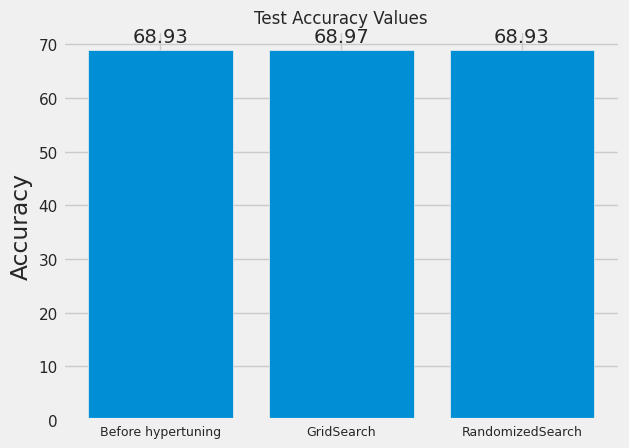

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# define the test accuracy values
accuracy_values = [test_Accuracy*100, test_acc1*100, test_acc2*100]

# create a list of x-axis values
x = np.arange(len(accuracy_values))

# create a new figure and axis object
fig, ax = plt.subplots()

# create the bars for the test accuracy values
bars = ax.bar(x, accuracy_values, align='center')

# set the x-axis tick labels
ax.set_xticks(x)
ax.set_xticklabels(['Before hypertuning','GridSearch','RandomizedSearch'],fontsize=9)

# set the title and axis labels
ax.set_title('Test Accuracy Values',fontsize=12)
ax.set_ylabel('Accuracy')

# add labels to the bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom')

# show the plot
plt.show()

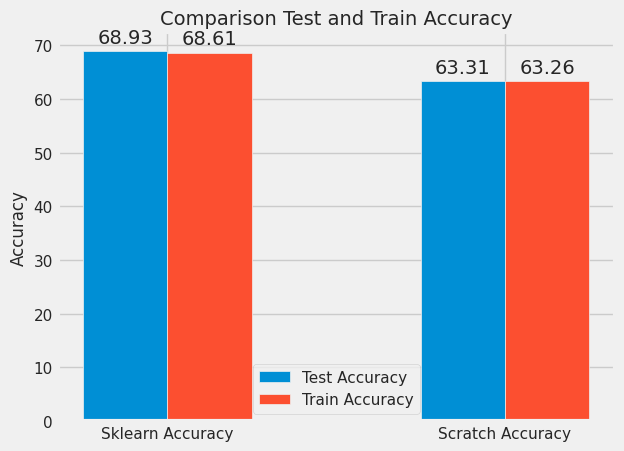

In [55]:
# define the accuracy values for the two models
Sklearn_test_accuracy = 68.93
Sklearn_train_accuracy = 68.61
Scratch_test_accuracy = 63.31
Scratch_train_accuracy = 63.26

# create a list of x-axis values
x = np.arange(2)

# set the width of each bar
width = 0.25

# create a new figure and axis object
fig, ax = plt.subplots()

# create the bars for the test accuracy values of the two models
test_bars1 = ax.bar(x - width/2, [Sklearn_test_accuracy, Scratch_test_accuracy], width, label='Test Accuracy')
# create the bars for the train accuracy values of the two models
train_bars1 = ax.bar(x + width/2, [Sklearn_train_accuracy, Scratch_train_accuracy], width, label='Train Accuracy')

# set the x-axis tick labels
ax.set_xticks(x)
ax.set_xticklabels(['Sklearn Accuracy', 'Scratch Accuracy'])

# set the title and axis labels
ax.set_title('Comparison Test and Train Accuracy',fontsize=14)
ax.set_ylabel('Accuracy',fontsize=12)

# add labels to the bars
for bar in test_bars1 + train_bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom')

# add a legend to the plot
ax.legend()
# show the plot
plt.show()